## Setup & Imports

In [13]:
4# Make the shared utils.py importable, then mount storage.
# If running locally, utils.py just needs to sit in the same folder as this notebook.
import sys, os

RUNNING_IN_COLAB = 'google.colab' in str(get_ipython())

if RUNNING_IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=True)
    PROJECT_DIR = '/content/drive/MyDrive/project/cv screening'
    os.makedirs(PROJECT_DIR, exist_ok=True)
    sys.path.append(PROJECT_DIR)
else:
    PROJECT_DIR = '.'

DATA_DIR = os.path.join(PROJECT_DIR, 'data')
os.makedirs(DATA_DIR, exist_ok=True)
print(f"PROJECT_DIR = {PROJECT_DIR}")
print(f"DATA_DIR    = {DATA_DIR}")

Mounted at /content/drive
PROJECT_DIR = /content/drive/MyDrive/project/cv screening
DATA_DIR    = /content/drive/MyDrive/project/cv screening/data


In [14]:
import sys, os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor, StackingRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', 20)
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Data Loading & Strict Grouped Split

In [28]:

df = pd.read_csv(f'{DATA_DIR}/ml_ready_dataset.csv')
df['flag_entry_level'] = df['flag_entry_level'].fillna(False).astype(int)

# Drop rows missing crucial fields (including text)
df = df.dropna(subset=['Processed_CV', 'Processed_JD', 'Cosine_Semantic', 'matched_score', 'Effective_Experience_Years'])
print(f"Clean Dataset shape: {df.shape}")



Clean Dataset shape: (9369, 12)


In [29]:
# GROUPED SPLIT: Prevents Candidate Memorization
gss = GroupShuffleSplit(n_splits=1, test_size=0.20
                        , random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df['job_position_name']))

df_train = df.iloc[train_idx].copy()
df_test = df.iloc[test_idx].copy()

y_train = df_train['matched_score'].values
y_test = df_test['matched_score'].values

print(f"Training Set: {len(df_train)} | Testing Set: {len(df_test)}")

Training Set: 7356 | Testing Set: 2013


## Safe Feature Engineering (No Data Leakage)

In [30]:
# PREVENT LEAKAGE: Fit TF-IDF only on training data
train_corpus = pd.concat([df_train['Processed_CV'], df_train['Processed_JD']]).fillna('')

safe_tfidf = TfidfVectorizer(stop_words='english', max_features=8000, ngram_range=(1, 2), sublinear_tf=True)
safe_tfidf.fit(train_corpus)

# Calculate safe cosine similarities using the fitted vectorizer
def calc_safe_tfidf(df_subset):
    cv_vecs = safe_tfidf.transform(df_subset['Processed_CV'].fillna(''))
    jd_vecs = safe_tfidf.transform(df_subset['Processed_JD'].fillna(''))
    return np.asarray(cv_vecs.multiply(jd_vecs).sum(axis=1)).ravel()

df_train['Safe_Cosine_TFIDF'] = calc_safe_tfidf(df_train)
df_test['Safe_Cosine_TFIDF']  = calc_safe_tfidf(df_test)

In [31]:
# PREVENT LEAKAGE: Fit Hybrid OLS ONLY on training data
ols = LinearRegression()
ols.fit(df_train[['Cosine_Semantic', 'Safe_Cosine_TFIDF']], df_train['matched_score'])

for d in (df_train, df_test):
    d['Safe_Cosine_Hybrid'] = ols.predict(d[['Cosine_Semantic', 'Safe_Cosine_TFIDF']])

## Define Features and Regularized Baseline Models

In [32]:
# Define Meta Columns
meta_cols = [
    'Effective_Experience_Years',
    'Experience_Penalty',
    'Cosine_Objective_Fit',

    'flag_entry_level'
] #     'Semantic_x_Experience',

# Define Feature Sets
features = {
    'TF-IDF Only': ['Safe_Cosine_TFIDF'] + meta_cols,
    'Semantic Only': ['Cosine_Semantic'] + meta_cols,
    'Hybrid (1D OLS)': ['Safe_Cosine_Hybrid'] + meta_cols,
    'All Text (Optimal)': ['Cosine_Semantic', 'Safe_Cosine_TFIDF'] + meta_cols
}

# Initialize Base Models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=300, max_depth=6, min_samples_leaf=20, n_jobs=-1),
    'Gradient Boost': HistGradientBoostingRegressor(random_state=42, max_iter=300, learning_rate=0.05, max_depth=4, min_samples_leaf=20)
}

## Standard Train and Evaluate Baseline Loop

In [33]:
results = []
fitted_artifacts = {}

# Train and Evaluate Loop (No extreme weights, no target transformers)
for fname, col_names in features.items():
    X_train = df_train[col_names].values
    X_test = df_test[col_names].values

    for mname, model_template in models.items():
        model = clone(model_template)
        scaler = StandardScaler()

        # Fit Scaler ONLY on Training Data to prevent leakage
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Standard fit
        model.fit(X_train_scaled, y_train)

        # Predict and strictly bound outputs to [0, 1] percentage format
        y_pred_raw = model.predict(X_test_scaled)
        y_pred = np.clip(y_pred_raw, 0, 1)

        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        results.append({'Feature Set': fname, 'Model': mname, 'R2-Score': r2, 'RMSE': rmse})
        fitted_artifacts[(fname, mname)] = (y_pred, model, scaler)

results_df = pd.DataFrame(results)
print("Models trained successfully!")
display(results_df.sort_values('R2-Score', ascending=False))

Models trained successfully!


,Feature Set,Model,R2-Score,RMSE
7,Semantic Only,Gradient Boost,0.320212,0.129136
11,Hybrid (1D OLS),Gradient Boost,0.289483,0.132022
4,Semantic Only,Linear Regression,0.273511,0.133498
5,Semantic Only,Ridge Regression,0.273482,0.133500
6,Semantic Only,Random Forest,0.249283,0.135705
10,Hybrid (1D OLS),Random Forest,0.226491,0.137750
8,Hybrid (1D OLS),Linear Regression,0.213539,0.138899
9,Hybrid (1D OLS),Ridge Regression,0.213518,0.138900
14,All Text (Optimal),Random Forest,0.204031,0.139736
15,All Text (Optimal),Gradient Boost,0.168255,0.142841


 BEST MODEL: Semantic Only + Gradient Boost (R2: 0.3202)


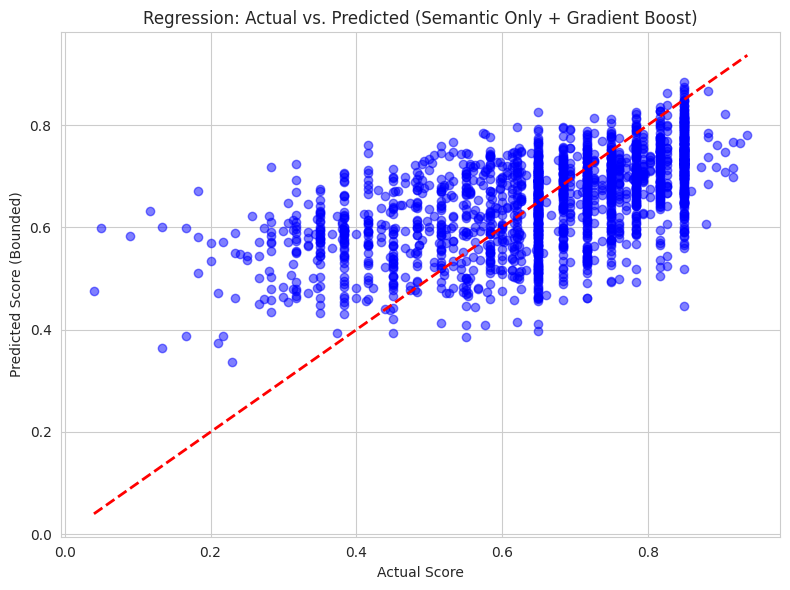

In [34]:
# Identify the ultimate winner
best_idx = results_df['R2-Score'].idxmax()
best_result = results_df.loc[best_idx]
best_fname = best_result['Feature Set']
best_mname = best_result['Model']

print(f" BEST MODEL: {best_fname} + {best_mname} (R2: {best_result['R2-Score']:.4f})")

# Extract the predictions for the best model
best_pred, _, _ = fitted_artifacts[(best_fname, best_mname)]

# Plot Actual vs Predicted Scatter
plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Regression: Actual vs. Predicted ({best_fname} + {best_mname})')
plt.ylabel('Predicted Score (Bounded)')
plt.xlabel('Actual Score')
plt.tight_layout()
plt.show()

In [35]:

best_pred, _, _ = fitted_artifacts[(best_fname, best_mname)]

# Create a DataFrame to compare the values side-by-side
comparison_df = pd.DataFrame({
    'Actual Score': y_test,
    'Predicted Score': best_pred,
    'Difference (Predicted - Actual)': best_pred - y_test,
    'Absolute Difference': np.abs(best_pred - y_test)
})

# Sort by Absolute Difference to see where the model was most accurate (or least accurate)
# Here we are just looking at the first 20 rows, rounded to 4 decimal places for clean reading
print("--- Actual vs. Predicted Value Comparison ---")
display(comparison_df.head(20).round(4))

--- Actual vs. Predicted Value Comparison ---


,Actual Score,Predicted Score,Difference (Predicted - Actual),Absolute Difference
0,0.4167,0.6753,0.2587,0.2587
1,0.8500,0.7404,-0.1096,0.1096
2,0.6267,0.6818,0.0551,0.0551
3,0.8500,0.7451,-0.1049,0.1049
4,0.6500,0.6317,-0.0183,0.0183
5,0.6500,0.5118,-0.1382,0.1382
6,0.7500,0.6698,-0.0802,0.0802
7,0.3833,0.6184,0.2350,0.2350
8,0.8500,0.7717,-0.0783,0.0783
9,0.8167,0.6731,-0.1436,0.1436


## Visualizations & Summary

 BEST MODEL: Semantic Only + Gradient Boost (R2: 0.3202)


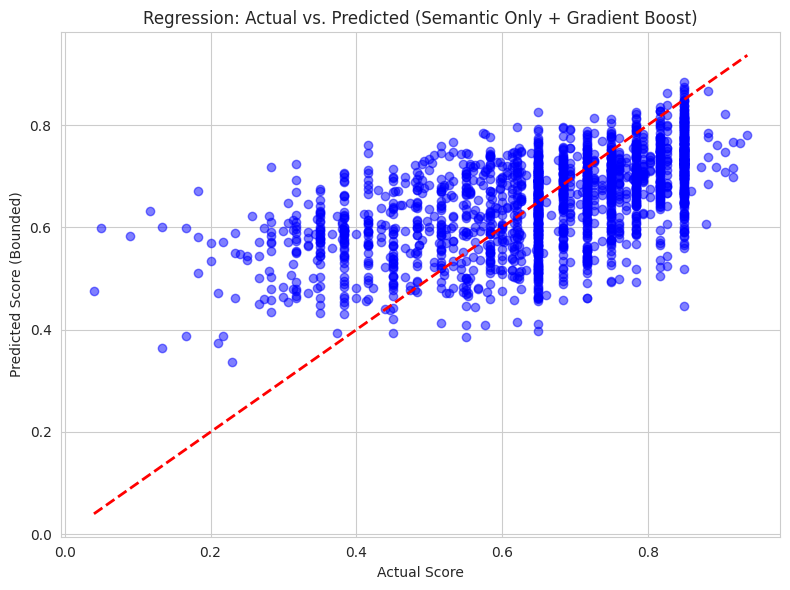

In [36]:
# Identify the ultimate winner
best_idx = results_df['R2-Score'].idxmax()
best_result = results_df.loc[best_idx]
best_fname = best_result['Feature Set']
best_mname = best_result['Model']

print(f" BEST MODEL: {best_fname} + {best_mname} (R2: {best_result['R2-Score']:.4f})")

# Extract the predictions for the best model
best_pred, _, _ = fitted_artifacts[(best_fname, best_mname)]

# Plot Actual vs Predicted Scatter
plt.figure(figsize=(8, 6))
plt.scatter(y_test, best_pred, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Regression: Actual vs. Predicted ({best_fname} + {best_mname})')
plt.ylabel('Predicted Score (Bounded)')
plt.xlabel('Actual Score')
plt.tight_layout()
plt.show()

In [ ]:
print("--- Training the Stacking Meta-Model ---")

# 1. Use the strongest feature set for the base models
stacking_features = features['Semantic Only']
X_train_stack = df_train[stacking_features].values
X_test_stack = df_test[stacking_features].values

scaler_stack = StandardScaler()
X_train_scaled = scaler_stack.fit_transform(X_train_stack)
X_test_scaled = scaler_stack.transform(X_test_stack)

# 2. Define Level 0 Base Models
base_estimators = [
    ('ridge', Ridge(alpha=1.0, random_state=42)),
    ('rf', RandomForestRegressor(random_state=42, n_estimators=300, max_depth=6, min_samples_leaf=20, n_jobs=-1)),
    ('gb', HistGradientBoostingRegressor(random_state=42, max_iter=300, learning_rate=0.05, max_depth=4, min_samples_leaf=20))
]

# 3. Train Level 1 Meta-Model (Linear Regression blending the base models)
stacker = StackingRegressor(
    estimators=base_estimators,
    final_estimator=LinearRegression(),
    cv=5,
    n_jobs=-1
)

stacker.fit(X_train_scaled, y_train)

# 4. Predict and Bound
y_pred_stack = np.clip(stacker.predict(X_test_scaled), 0, 1)

r2_stack = r2_score(y_test, y_pred_stack)
rmse_stack = np.sqrt(mean_squared_error(y_test, y_pred_stack))

print(f"Meta-Model Performance -> R²: {r2_stack:.4f} | RMSE: {rmse_stack:.4f}")

--- Training the Stacking Meta-Model ---


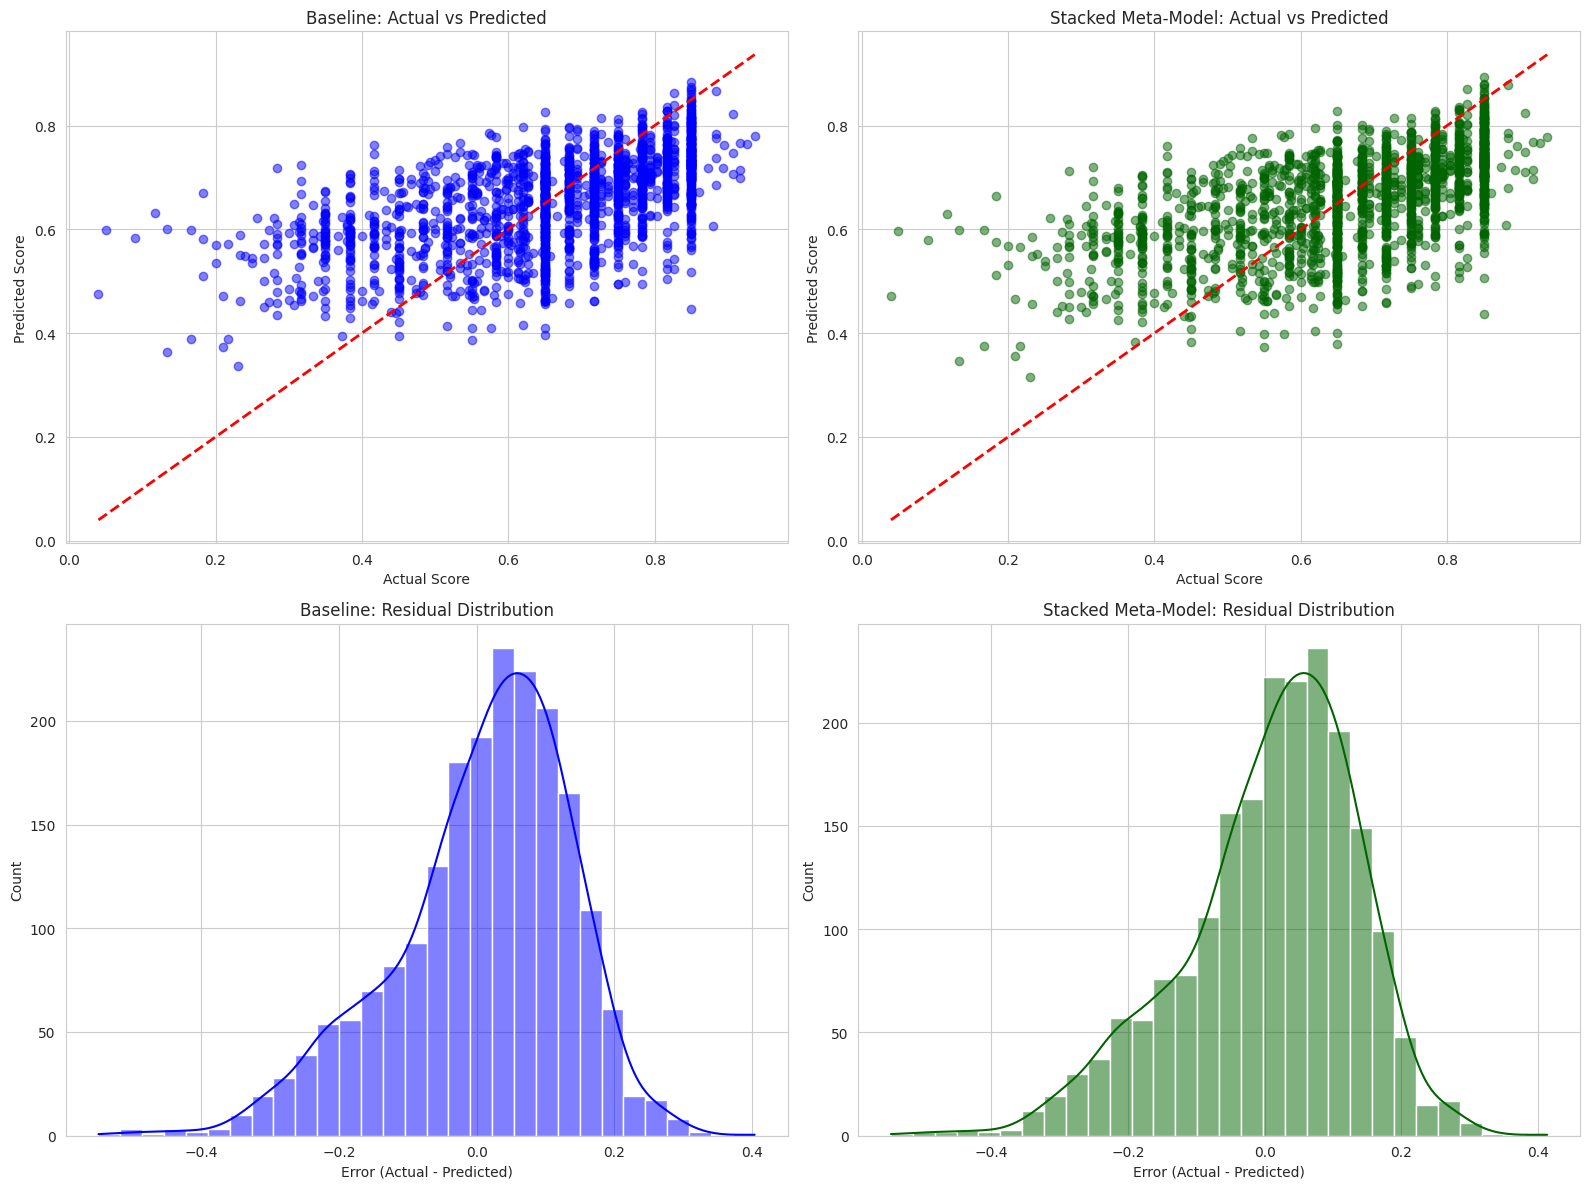

In [ ]:
# Extract the best baseline prediction for comparison
best_base_pred, _, _ = fitted_artifacts[('Semantic Only', 'Gradient Boost')]

# Calculate Residuals (Actual - Predicted)
res_base = y_test - best_base_pred
res_stack = y_test - y_pred_stack

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Actual vs Predicted (Baseline)
axes[0, 0].scatter(y_test, best_base_pred, alpha=0.5, color='blue')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_title('Baseline: Actual vs Predicted')
axes[0, 0].set_xlabel('Actual Score')
axes[0, 0].set_ylabel('Predicted Score')

# 2. Actual vs Predicted (Stacked)
axes[0, 1].scatter(y_test, y_pred_stack, alpha=0.5, color='darkgreen')
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 1].set_title('Stacked Meta-Model: Actual vs Predicted')
axes[0, 1].set_xlabel('Actual Score')
axes[0, 1].set_ylabel('Predicted Score')

# 3. Residuals (Baseline)
sns.histplot(res_base, kde=True, ax=axes[1, 0], color='blue', bins=30)
axes[1, 0].set_title('Baseline: Residual Distribution')
axes[1, 0].set_xlabel('Error (Actual - Predicted)')

# 4. Residuals (Stacked)
sns.histplot(res_stack, kde=True, ax=axes[1, 1], color='darkgreen', bins=30)
axes[1, 1].set_title('Stacked Meta-Model: Residual Distribution')
axes[1, 1].set_xlabel('Error (Actual - Predicted)')

plt.tight_layout()
plt.show()

In [ ]:
print("\n--- Final Test Set Evaluation ---")

# Apply the 0.65 Optimal Threshold determined earlier
final_report_df = pd.DataFrame({
    'Actual Score': y_test,
    'Baseline Prediction': best_base_pred,
    'Stacked Prediction': y_pred_stack,
    'Stacking Absolute Error': np.abs(y_test - y_pred_stack),
    'HR Decision (Thresh 0.65)': np.where(y_pred_stack >= 0.65, 'Accepted', 'Rejected')
})

display(final_report_df.head(15).round(3))


--- Final Test Set Evaluation ---


,Actual Score,Baseline Prediction,Stacked Prediction,Stacking Absolute Error,HR Decision (Thresh 0.65)
0,0.417,0.675,0.677,0.261,Accepted
1,0.850,0.740,0.739,0.111,Accepted
2,0.627,0.682,0.685,0.058,Accepted
3,0.850,0.745,0.742,0.108,Accepted
4,0.650,0.632,0.634,0.016,Rejected
5,0.650,0.512,0.509,0.141,Rejected
6,0.750,0.670,0.670,0.080,Accepted
7,0.383,0.618,0.619,0.236,Rejected
8,0.850,0.772,0.779,0.071,Accepted
9,0.817,0.673,0.670,0.146,Accepted


--- TOP 10 FEATURE & METADATA COMBINATIONS ---


,Text Strategy,Model,Metadata Combination,R2-Score,RMSE
423,Semantic Only,Gradient Boost,Effective_Experience_Years + Experience_Penalt...,0.3202,0.1291
487,Semantic Only,Gradient Boost,Effective_Experience_Years + Experience_Penalt...,0.3154,0.1296
247,Semantic Only,Gradient Boost,Effective_Experience_Years + Experience_Penalt...,0.3072,0.1304
311,Semantic Only,Gradient Boost,Effective_Experience_Years + Cosine_Objective_...,0.3045,0.1306
295,Semantic Only,Gradient Boost,Effective_Experience_Years + Cosine_Objective_...,0.3013,0.1309
455,Semantic Only,Gradient Boost,Effective_Experience_Years + Cosine_Objective_...,0.2990,0.1311
103,Semantic Only,Gradient Boost,Effective_Experience_Years + Cosine_Objective_Fit,0.2968,0.1313
107,Hybrid (1D OLS),Gradient Boost,Effective_Experience_Years + Cosine_Objective_Fit,0.2936,0.1316
407,Semantic Only,Gradient Boost,Effective_Experience_Years + Experience_Penalt...,0.2927,0.1317
427,Hybrid (1D OLS),Gradient Boost,Effective_Experience_Years + Experience_Penalt...,0.2895,0.1320



🌟 BEST MODEL: Semantic Only | Gradient Boost | R²: 0.3202 | RMSE: 0.1291
Metadata Features Used: Effective_Experience_Years + Experience_Penalty + Cosine_Objective_Fit + flag_entry_level


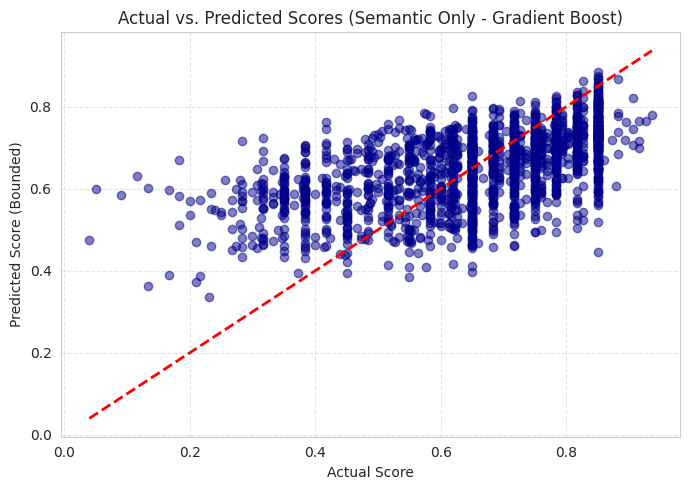

In [27]:
import itertools
from sklearn.base import clone


# 1. Define metadata pool
cols = [
    'Effective_Experience_Years',
    'Experience_Penalty',
    'Cosine_Objective_Fit',
    'Semantic_x_Experience',
    'flag_entry_level',
]

results = []
fitted_artifacts = {}

# 2. Iterate through all combinations of metadata features (1 to 5)
for r in range(1, len(cols) + 1):
  for combo in itertools.combinations(cols, r):
    meta_cols = list(combo)
    meta_str = ' + '.join(meta_cols)

    # Build feature sets for the current metadata combination
    features = {
        'TF-IDF Only': ['Safe_Cosine_TFIDF'] + meta_cols,
        'Semantic Only': ['Cosine_Semantic'] + meta_cols,
        'Hybrid (1D OLS)': ['Safe_Cosine_Hybrid'] + meta_cols,
        'All Text (Optimal)': [
            'Cosine_Semantic',
            'Safe_Cosine_TFIDF',
        ]
        + meta_cols,
    }

    # Evaluate across all text strategies and models
    for text_strategy, col_names in features.items():
      X_train = df_train[col_names].values
      X_test = df_test[col_names].values

      for mname, model_template in models.items():
        # Scale training data to prevent leakage
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # Train & Predict
        model = clone(model_template)
        model.fit(X_train_scaled, y_train)
        y_pred = np.clip(model.predict(X_test_scaled), 0, 1)

        # Compute Metrics
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))

        key = (text_strategy, meta_str, mname)
        results.append({
            'Text Strategy': text_strategy,
            'Model': mname,
            'Metadata Combination': meta_str,
            'R2-Score': r2,
            'RMSE': rmse,
            'key': key,
        })
        fitted_artifacts[key] = y_pred

# 3. Create Summary DataFrame & Display Top 10
results_df = pd.DataFrame(results)

print('--- TOP 10 FEATURE & METADATA COMBINATIONS ---')
display(
    results_df.sort_values('R2-Score', ascending=False)
    .drop(columns=['key'])
    .head(20)
    .round(4)
)

# 4. Extract and Print Best Model Overall
best_row = results_df.loc[results_df['R2-Score'].idxmax()]
best_pred = fitted_artifacts[best_row['key']]

print(
    f"\n🌟 BEST MODEL: {best_row['Text Strategy']} | {best_row['Model']} | R²:"
    f" {best_row['R2-Score']:.4f} | RMSE: {best_row['RMSE']:.4f}"
)
print(f"Metadata Features Used: {best_row['Metadata Combination']}")

# 5. Plot Actual vs. Predicted for the Best Model
plt.figure(figsize=(7, 5))
plt.scatter(y_test, best_pred, alpha=0.5, color='darkblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(
    f"Actual vs. Predicted Scores ({best_row['Text Strategy']} - {best_row['Model']})"
)
plt.xlabel('Actual Score')
plt.ylabel('Predicted Score (Bounded)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()